In [ ]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

!pip install mxnet
!pip install gluonnlp==0.9.1 pandas tqdm
!pip install sentencepiece
!pip install transformers
!pip install torch
!pip install 'git+https://github.com/SKTBrain/KoBERT.git#egg=kobert_tokenizer&subdirectory=kobert_hf'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 MB 16.3 MB/s eta 0:00:00
  Attempting uninstall: graphviz
    Found existing installation: graphviz 0.20.1
    Uninstalling graphviz-0.20.1:
      Successfully uninstalled graphviz-0.20.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for gluonnlp: filename=gluonnlp-0.9.1-cp310-cp310-linux_x86_64.whl size=564601 sha256=5d0888858d0345520318c503ae65f44b30c2c23f39b4873b88d4fe86aee912d5
  Stored in directory: /root/.cache/pip/wheels/fc/5b/9c/3295bb07f7c5544a96303a48988707816f44a536e8e1413922
Successfully built gluonnlp
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.2 MB/s eta 0:00:00
  Cloning https://github.com/SKTBrain/KoBERT.git to /tmp/pip-install-_3tywvw_/kobert-tokenizer_4124b3e8c5ff4a97a2cb453a9d2755af
  Running command git clone --filter=blob:none --quiet https://github.com/SKTBrain/KoBERT.git /tmp/pip-install-_3tywvw_/kobe

In [ ]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertModel, AdamW, get_cosine_schedule_with_warmup
import pandas as pd
from sklearn.model_selection import train_test_split
from kobert_tokenizer import KoBERTTokenizer
from torch.nn.utils.rnn import pad_sequence

# Define the BERTDataset class
class BERTDataset(Dataset):
    def __init__(self, dataset, sent_idx, label_idx, max_len, tokenizer):
        self.sentences = [tokenizer.encode(i[sent_idx], max_length=max_len,
                                           truncation=True) for i in dataset]
        self.labels = [i[label_idx] for i in dataset]
        self.max_len = max_len

    def __getitem__(self, i):
        # Right-pad the token_ids up to self.max_len
        token_ids = self.sentences[i] + [tokenizer.pad_token_id] * (self.max_len - len(self.sentences[i]))
        return torch.tensor(token_ids, dtype=torch.long), torch.tensor(self.labels[i], dtype=torch.long)

    def __len__(self):
        return len(self.labels)


# Define the BERTClassifier class
class BERTClassifier(nn.Module):
    def __init__(self, bert, hidden_size=768, num_classes=27, dr_rate=None):
        super(BERTClassifier, self).__init__()
        self.bert = bert
        self.classifier = nn.Linear(hidden_size, num_classes)
        self.dropout = nn.Dropout(p=dr_rate) if dr_rate else None

    def forward(self, token_ids):
        # Create an attention mask
        # Attention mask values are 1 for non-padding tokens and 0 for padding
        attention_mask = (token_ids != tokenizer.pad_token_id).float()

        # Pass the attention mask to the BERT model
        output = self.bert(input_ids=token_ids, attention_mask=attention_mask)
        pooled_output = output.pooler_output
        if self.dropout:
            pooled_output = self.dropout(pooled_output)
        return self.classifier(pooled_output)



# Load and preprocess dataset
from google.colab import drive
drive.mount('/content/drive')
train_data = pd.read_csv('/content/drive/MyDrive/27_emotion_sentence.csv', encoding='utf-8')




# Label mapping. Note: Must start from "0".
label_mapping = {
    "분노": 0, "낙관": 1, "두려움": 2, "당혹감": 3, "슬픔": 4,
    "자랑스러움": 5, "혼란": 6, "반감": 7, "걱정": 8, "비통": 9,
    "안도": 10, "기쁨": 11, "실망": 12, "갈망": 13, "회한": 14,
    "혐오": 15, "흥분": 16, "놀라움": 17, "짜증": 18, "호기심": 19,
    "감사": 20, "재미": 21, "감탄": 22, "인정": 23, "배려": 24,
    "사랑": 25, "깨달음": 26
}

# Apply the mapping to labels
train_data['Emotion_2'] = train_data['Emotion_2'].map(label_mapping)


Mounted at /content/drive


In [ ]:
# Initialize tokenizer and model
tokenizer = KoBERTTokenizer.from_pretrained('skt/kobert-base-v1')
bert_model = BertModel.from_pretrained('skt/kobert-base-v1')

# Prepare datasets
max_len = 512
train_set, test_set = train_test_split(train_data[['Sentence', 'Emotion_2']].values.tolist(), test_size=0.2, random_state=4)

train_dataset = BERTDataset(train_set, 0, 1, max_len, tokenizer)
test_dataset = BERTDataset(test_set, 0, 1, max_len, tokenizer)

# Prepare data loaders
batch_size = 16
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

# Define calc_accuracy function
def calc_accuracy(out, labels):
    predictions = torch.argmax(out, dim=1)
    correct = (predictions == labels).float()
    accuracy = correct.sum() / len(correct)
    return accuracy

# Set up the optimizer and scheduler
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BERTClassifier(bert_model, dr_rate=0.5).to(device)
optimizer = AdamW(model.parameters(), lr=5e-5)
loss_fn = nn.CrossEntropyLoss()

tokenizer_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/371k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/244 [00:00<?, ?B/s]

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'XLNetTokenizer'. 
The class this function is called from is 'KoBERTTokenizer'.


config.json:   0%|          | 0.00/535 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/369M [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [ ]:
from transformers import get_cosine_schedule_with_warmup

# Configuration
warmup_ratio = 0.1
num_epochs = 5
max_grad_norm = 1.0

# Create the learning rate scheduler
num_training_steps = len(train_dataloader) * num_epochs
num_warmup_steps = int(num_training_steps * warmup_ratio)
scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=num_warmup_steps, num_training_steps=num_training_steps)

In [ ]:
from tqdm import tqdm
torch.backends.cudnn.deterministic = True


# Training loop
for epoch in range(num_epochs):
    model.train()  # Tell the model to set itself to training mode
    train_acc = 0.0
    train_loss = 0.0

    for batch_id, (token_ids, labels) in enumerate(tqdm(train_dataloader, desc='Training')):
        token_ids = token_ids.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        output = model(token_ids)  # Pass token_ids and the model will handle the attention mask


        loss = loss_fn(output, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()
        scheduler.step()  # Update learning rate schedule

        train_acc += calc_accuracy(output, labels)
        train_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss/(batch_id+1)} | Train Accuracy: {train_acc/(batch_id+1)}")

    # Validation phase
    model.eval()
    test_acc = 0.0

    with torch.no_grad():
        for batch_id, (token_ids, labels) in enumerate(tqdm(test_dataloader, desc='Validation')):
            token_ids = token_ids.to(device)
            labels = labels.to(device)

            output = model(token_ids)  # Pass only token_ids
            test_acc += calc_accuracy(output, labels)

    print(f"Epoch {epoch+1}/{num_epochs} | Test Accuracy: {test_acc/(batch_id+1)}")


Training:   2%|▏         | 23/1487 [00:34<36:05,  1.48s/it]


KeyboardInterrupt: ignored

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Validation phase
model.eval()
test_acc = 0.0
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_id, (token_ids, labels) in enumerate(tqdm(test_dataloader, desc='Validation')):
        token_ids = token_ids.to(device)
        labels = labels.to(device)

        output = model(token_ids)  # Pass only token_ids
        test_acc += calc_accuracy(output, labels)

        # Store predictions and true labels
        preds = torch.argmax(output, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"Epoch {epoch+1}/{num_epochs} | Test Accuracy: {test_acc/(batch_id+1)}")

# Calculate and print the classification report
print(classification_report(all_labels, all_preds))

In [ ]:
## 학습 모델 저장
PATH = 'content/drive/MyDrive/' # google 드라이브 연동 해야함. 관련코드는 뺐음
torch.save(model, PATH + 'KoBERT_27_emotion.pt')  # 전체 모델 저장
torch.save(model.state_dict(), PATH + 'model_state_dict.pt')  # 모델 객체의 state_dict 저장
torch.save({
    'model': model.state_dict(),
    'optimizer': optimizer.state_dict()
}, PATH + 'all.tar')  # 여러 가지 값 저장, 학습 중 진행 상황 저장을 위해 epoch, loss 값 등 일반 scalar값 저장 가능

RuntimeError: ignored

In [ ]:
#신규 데이터 학습을 위한 튜닝모델 불러오기(라이브러리 설치)

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertModel, AdamW, get_cosine_schedule_with_warmup
import pandas as pd
from sklearn.model_selection import train_test_split
from kobert_tokenizer import KoBERTTokenizer
from torch.nn.utils.rnn import pad_sequence

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
#저장한 모델 불러오기
device = "cuda" if torch.cuda.is_available() else "cpu"
model =  BertModel.from_pretrained('skt/kobert-base-v1')
bert_model = BertModel.from_pretrained('skt/kobert-base-v1')
model_state_dict = torch.load("/content/drive/MyDrive/emotion_class_model.pth", map_location=device)
model.eval()

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(8002, 768, padding_idx=1)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
   

In [ ]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertModel, AdamW, get_cosine_schedule_with_warmup
import pandas as pd
from sklearn.model_selection import train_test_split
from kobert_tokenizer import KoBERTTokenizer
from torch.nn.utils.rnn import pad_sequence

# Define the BERTDataset class
class BERTDataset(Dataset):
    def __init__(self, dataset, sent_idx, label_idx, max_len, tokenizer):
        self.sentences = [tokenizer.encode(i[sent_idx], max_length=max_len,
                                           truncation=True) for i in dataset]
        self.labels = [i[label_idx] for i in dataset]
        self.max_len = max_len

    def __getitem__(self, i):
        # Right-pad the token_ids up to self.max_len
        token_ids = self.sentences[i] + [tokenizer.pad_token_id] * (self.max_len - len(self.sentences[i]))
        return torch.tensor(token_ids, dtype=torch.long), torch.tensor(self.labels[i], dtype=torch.long)

    def __len__(self):
        return len(self.labels)


# Define the BERTClassifier class
class BERTClassifier(nn.Module):
    def __init__(self, bert, hidden_size=768, num_classes=27, dr_rate=None):
        super(BERTClassifier, self).__init__()
        self.bert = bert
        self.classifier = nn.Linear(hidden_size, num_classes)
        self.dropout = nn.Dropout(p=dr_rate) if dr_rate else None

    def forward(self, token_ids):
        # Create an attention mask
        # Attention mask values are 1 for non-padding tokens and 0 for padding
        attention_mask = (token_ids != tokenizer.pad_token_id).float()

        # Pass the attention mask to the BERT model
        output = self.bert(input_ids=token_ids, attention_mask=attention_mask)
        pooled_output = output.pooler_output
        if self.dropout:
            pooled_output = self.dropout(pooled_output)
        return self.classifier(pooled_output)

#새로운 데이터 불러오기
new_data = pd.read_csv('/content/drive/MyDrive/감성대화말뭉치_Training.csv', encoding='utf-8')

# Label mapping. Note: Must start from "0".
label_mapping = {
    "분노": 0, "낙관": 1, "두려움": 2, "당혹감": 3, "슬픔": 4,
    "자랑스러움": 5, "혼란": 6, "반감": 7, "걱정": 8, "비통": 9,
    "안도": 10, "기쁨": 11, "실망": 12, "갈망": 13, "회한": 14,
    "혐오": 15, "흥분": 16, "놀라움": 17, "짜증": 18, "호기심": 19,
    "감사": 20, "재미": 21, "감탄": 22, "인정": 23, "배려": 24,
    "사랑": 25, "깨달음": 26
}

# Apply the mapping to labels
new_data['2차분류'] = new_data['2차분류'].map(label_mapping)




In [ ]:
new_data['2차분류'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26])

In [ ]:
# 저장한 모델 및 상태사전 불러오기
tokenizer = KoBERTTokenizer.from_pretrained('skt/kobert-base-v1')
model =  torch.load('/content/drive/MyDrive/KoBERT_27_emotion.pt')
model_state_dict = torch.load("/content/drive/MyDrive/emo_model_state_dict.pt", map_location=device)

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'XLNetTokenizer'. 
The class this function is called from is 'KoBERTTokenizer'.


In [ ]:
model.eval()

BERTClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(8002, 768, padding_idx=1)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_aff

In [ ]:
bert_model.config.hidden_size

768

In [ ]:
!pip install pytorch_lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 776.9/776.9 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 806.1/806.1 kB 11.8 MB/s eta 0:00:00


In [ ]:
### lightning.metrics --> torchmetrics로 변경

import pytorch_lightning as pl
from torchmetrics.functional import accuracy,f1_score,auroc
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import TensorBoardLogger

In [ ]:
class BERTClassifier(nn.Module):
    def __init__(self, bert, hidden_size=768, num_classes=27, dr_rate=None):
        super(BERTClassifier, self).__init__()
        self.bert = bert
        self.classifier = nn.Linear(hidden_size, num_classes)
        self.dropout = nn.Dropout(p=dr_rate) if dr_rate else None

    def forward(self, token_ids):
        # Create an attention mask
        # Attention mask values are 1 for non-padding tokens and 0 for padding
        attention_mask = (token_ids != tokenizer.pad_token_id).float()

        # Pass the attention mask to the BERT model
        output = self.bert(input_ids=token_ids, attention_mask=attention_mask)
        pooled_output = output.pooler_output
        if self.dropout:
            pooled_output = self.dropout(pooled_output)
        return self.classifier(pooled_output)


class BERTDatasete(pl.LightningDataModule):
    def __init__(self, dataset, sent_idx, label_idx, max_len, tokenizer):
        self.sentences = [tokenizer.encode(i[sent_idx], max_length=max_len,
                                           truncation=True) for i in dataset]
        self.labels = [i[label_idx] for i in dataset]
        self.max_len = max_len

    def __getitem__(self, i):
        # Right-pad the token_ids up to self.max_len
        token_ids = self.sentences[i] + [tokenizer.pad_token_id] * (self.max_len - len(self.sentences[i]))
        return torch.tensor(token_ids, dtype=torch.long), torch.tensor(self.labels[i], dtype=torch.long)

    def __len__(self):
        return len(self.labels)

In [ ]:
#새로운 데이터 불러오기
new_data = pd.read_csv('/content/drive/MyDrive/감성대화말뭉치_Training.csv', encoding='utf-8')

# Label mapping. Note: Must start from "0".
label_mapping = {
    "분노": 0, "낙관": 1, "두려움": 2, "당혹감": 3, "슬픔": 4,
    "자랑스러움": 5, "혼란": 6, "반감": 7, "걱정": 8, "비통": 9,
    "안도": 10, "기쁨": 11, "실망": 12, "갈망": 13, "회한": 14,
    "혐오": 15, "흥분": 16, "놀라움": 17, "짜증": 18, "호기심": 19,
    "감사": 20, "재미": 21, "감탄": 22, "인정": 23, "배려": 24,
    "사랑": 25, "깨달음": 26
}

In [ ]:
# Apply the mapping to labels
new_data['2차분류'] = new_data['2차분류'].map(label_mapping)

In [ ]:
# Prepare datasets
max_len = 512
train_set, test_set = train_test_split(new_data[['F_Sentence', '2차분류']].values.tolist(), test_size=0.2, random_state=4)

train_dataset = BERTDataset(train_set, 0, 1, max_len, tokenizer)
test_dataset = BERTDataset(test_set, 0, 1, max_len, tokenizer)

# Prepare data loaders
batch_size = 16
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

# Define calc_accuracy function
def calc_accuracy(out, labels):
    predictions = torch.argmax(out, dim=1)
    correct = (predictions == labels).float()
    accuracy = correct.sum() / len(correct)
    return accuracy

# Set up the optimizer and scheduler
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BERTClassifier(bert_model, dr_rate=0.5).to(device)
optimizer = AdamW(model.parameters(), lr=5e-5)
loss_fn = nn.CrossEntropyLoss()

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [ ]:
from transformers import AdamW, get_linear_schedule_with_warmup
import torch.nn as nn

class BERTClassifier(nn.Module):

    def __init__(self, n_classes: int, n_training_steps=None, n_warmup_steps= None):
        super().__init__()
        self.bert = bert_model
        self.classifier = nn.Linear(self.bert.config.hidden_size, n_classes)
        self.n_training_steps = n_training_steps
        self.n_warmup_steps = n_warmup_steps
        self.criterion = nn.BCELoss()

    def forward(self, input_ids, attention_mask, labels= None):
        output = self.bert(input_ids, attention_mask = attention_mask)
        output = self.classifier(output.pooler_output)
        output = torch.sigmoid(output)
        loss = 0
        if labels is not None:
            loss = self.criterion(output, labels)
        return loss, output

    def training_step(self, batch, batch_idx):
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["labels"]
        loss,outputs = self(input_ids, attention_mask, labels)
        self.log("val_loss", loss, prog_bar =True, logger = True)
        return {"loss": loss, "predictions": outputs, "labels": labels}

    def test_step(self, batch, batch_idx):
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["labels"]
        loss,outputs = self(input_ids, attention_mask, labels)
        self.log("val_loss", loss, prog_bar =True, logger = True)
        return loss

    def training_epoch_end(self, outputs):
        labels = []
        predictions = []
        for output in outputs:
            for out_labels in output["labels"].detach().cpu():
                labels.append(out_labels)
            for out_predictions in output["predictions"].detach().cpu():
                predictions.append(out_predictions)

        labels = torch.stack(labels).int()
        predictions = torch.stack(predictions)

        for i, name in enumerate('2차분류'):
            class_roc_auc = auroc(predictions[:,i],labels[:,i])
            self.logger.experiment.add_scalar(f"{name}_roc_auc/Train", class_roc_auc, self.current_epoch)

    def configure_optimizers(self):
        optimizer = AdamW(self.parameters(), lr= 5e-5)

        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps= self.n_warmup_steps,
            num_training_steps = self.n_training_steps
        )

        return dict(
            optimizer=optimizer,
            lr_scheduler = dict(
            scheduler = scheduler,
            interval='step'
        )
    )


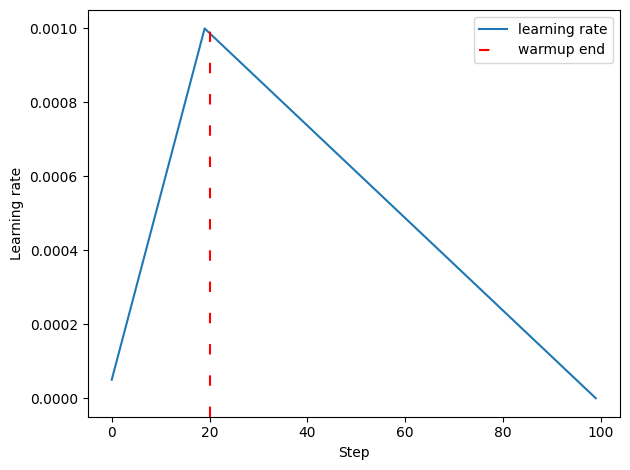

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

dummy_model = nn.Linear(2,1)

optimizer = AdamW(params=dummy_model.parameters(),lr=0.001)

warmup_steps = 20
total_training_steps = 100

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps = warmup_steps,
    num_training_steps = total_training_steps
)

learning_rate_history = []

for step in range(total_training_steps):
    optimizer.step()
    scheduler.step()
    learning_rate_history.append(optimizer.param_groups[0]['lr'])

plt.plot(learning_rate_history, label="learning rate")
plt.axvline(x=warmup_steps, color="red", linestyle=(0, (5, 10)), label="warmup end")
plt.legend()
plt.xlabel("Step")
plt.ylabel("Learning rate")
plt.tight_layout();

In [ ]:
steps_per_epoch = len(train_dataset)
total_training_steps = steps_per_epoch * N_EPOCHS

In [ ]:
warmup_steps = total_training_steps//5
warmup_steps, total_training_steps

(41304, 206520)

In [ ]:
model = BERTClassifier(
    n_classes=len('2차분류'),
    n_warmup_steps = warmup_steps,
    n_training_steps = total_training_steps
)

In [ ]:
criterion = nn.BCELoss()

prediction = torch.FloatTensor(
    [10.95873564, 1.07321467, 1.58524066, 0.03839076, 15.72987556, 1.09513213]
)

labels = torch.FloatTensor(
    [1. ,0. ,0. ,0. ,1. ,0. ]
)

In [ ]:
torch.sigmoid(prediction)

tensor([1.0000, 0.7452, 0.8299, 0.5096, 1.0000, 0.7493])

In [ ]:
criterion(torch.sigmoid(prediction),labels)

tensor(0.8725)

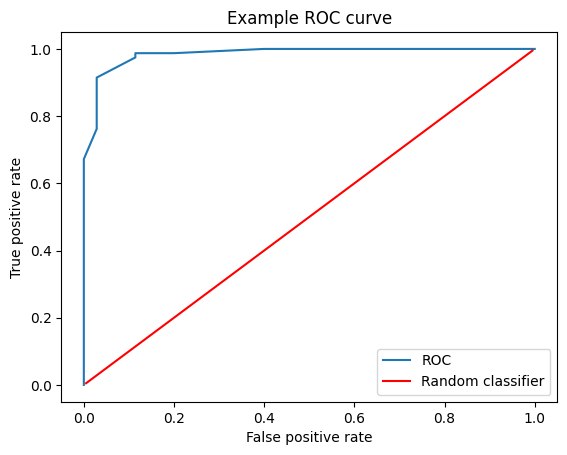

In [ ]:

from sklearn import metrics

fpr = [0.        , 0.        , 0.        , 0.02857143, 0.02857143,
       0.11428571, 0.11428571, 0.2       , 0.4       , 1.        ]
tpr = [0.        , 0.01265823, 0.67202532, 0.76202532, 0.91468354,
       0.97468354, 0.98734177, 0.98734177, 1.        , 1.        ]
_, ax = plt.subplots()
ax.plot(fpr, tpr, label="ROC")
ax.plot([0.05, 0.95], [0.05, 0.95], transform=ax.transAxes, label="Random classifier", color="red")
ax.legend(loc=4)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("Example ROC curve")
plt.show();

In [ ]:

### 체크포인트 생성
checkpoint_callback = ModelCheckpoint(
  dirpath="checkpoints",
  filename="best-checkpoint",
  save_top_k=1,
  verbose=True,
  monitor="val_loss",
  mode="min"
)

In [ ]:

logger = TensorBoardLogger("lightning_logs", name="emotion_classifier")

In [ ]:

early_stopping_callback = EarlyStopping(monitor='val_loss', patience=2)

In [ ]:
trainer = pl.Trainer(
  logger=logger,
  callbacks=[checkpoint_callback, early_stopping_callback],
  max_epochs=N_EPOCHS,
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


In [ ]:
if not isinstance(model, (LightningModule, torch._dynamo.OptimizedModule)):
    raise TypeError(
        f"`model` must be a `LightningModule` or `torch._dynamo.OptimizedModule`, got `{type(model).__qualname__}`"
    )

trainer.fit(model, Dataset)

NameError: ignored

In [ ]:
#신규데이터 불러오기 + 구분하기
sample_sentence = train_data.iloc[17]
sample_comment = sample_sentence['문장']
sample_labels = sample_sentence[LABEL_COLUMNS]

print(sample_comment)
print()
print(sample_labels.to_dict())

In [ ]:


# Prepare datasets
max_len = 512
train_set, test_set = train_test_split(new_data[['F_Sentence', '2차분류']].values.tolist(), test_size=0.2, random_state=4)

train_dataset = BERTDataset(train_set, 0, 1, max_len, tokenizer)
test_dataset = BERTDataset(test_set, 0, 1, max_len, tokenizer)

# Prepare data loaders
batch_size = 16
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

# Define calc_accuracy function
def calc_accuracy(out, labels):
    predictions = torch.argmax(out, dim=1)
    correct = (predictions == labels).float()
    accuracy = correct.sum() / len(correct)
    return accuracy

# Set up the optimizer and scheduler
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BERTClassifier(bert_model, dr_rate=0.5).to(device)
optimizer = AdamW(model.parameters(), lr=5e-5)
loss_fn = nn.CrossEntropyLoss()

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'XLNetTokenizer'. 
The class this function is called from is 'KoBERTTokenizer'.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [ ]:
from transformers import get_cosine_schedule_with_warmup

# Configuration
warmup_ratio = 0.1
num_epochs = 3
max_grad_norm = 1.0

# Create the learning rate scheduler
num_training_steps = len(train_dataloader) * num_epochs
num_warmup_steps = int(num_training_steps * warmup_ratio)
scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=num_warmup_steps, num_training_steps=num_training_steps)

In [ ]:
from tqdm import tqdm
torch.backends.cudnn.deterministic = True


# Training loop
for epoch in range(num_epochs):
    model.train()  # Training mode
    train_acc = 0.0
    train_loss = 0.0

    for batch_id, (token_ids, labels) in enumerate(tqdm(train_dataloader, desc='Training')):
        token_ids = token_ids.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        output = model(token_ids)  # Pass token_ids and the model will handle the attention mask


        loss = loss_fn(output, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()
        scheduler.step()  # Update learning rate schedule

        train_acc += calc_accuracy(output, labels)
        train_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss/(batch_id+1)} | Train Accuracy: {train_acc/(batch_id+1)}")

    # Validation phase
    model.eval()
    test_acc = 0.0

    with torch.no_grad():
        for batch_id, (token_ids, labels) in enumerate(tqdm(test_dataloader, desc='Validation')):
            token_ids = token_ids.to(device)
            labels = labels.to(device)

            output = model(token_ids)  # Pass only token_ids
            test_acc += calc_accuracy(output, labels)

    print(f"Epoch {epoch+1}/{num_epochs} | Test Accuracy: {test_acc/(batch_id+1)}")

Training:  94%|█████████▍| 2421/2582 [58:14<03:52,  1.44s/it]


KeyboardInterrupt: ignored

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Validation phase
model.eval()
test_acc = 0.0
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_id, (token_ids, labels) in enumerate(tqdm(test_dataloader, desc='Validation')):
        token_ids = token_ids.to(device)
        labels = labels.to(device)

        output = model(token_ids)  # Pass only token_ids
        test_acc += calc_accuracy(output, labels)

        # Store predictions and true labels
        preds = torch.argmax(output, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"Epoch {epoch+1}/{num_epochs} | Test Accuracy: {test_acc/(batch_id+1)}")

# Calculate and print the classification report
print(classification_report(all_labels, all_preds))


Validation:   0%|          | 0/372 [00:00<?, ?it/s]


RuntimeError: ignored